In [1]:
import time
import statistics
import heapq
from collections import Counter

def rearrange_string(s):
    freq = Counter(s)

    # Max heap using negative frequencies
    heap = [(-count, char) for char, count in freq.items()]
    heapq.heapify(heap)

    result = []

    while len(heap) >= 2:
        count1, char1 = heapq.heappop(heap)
        count2, char2 = heapq.heappop(heap)

        result.append(char1)
        result.append(char2)

        count1 += 1
        count2 += 1

        if count1 < 0:
            heapq.heappush(heap, (count1, char1))

        if count2 < 0:
            heapq.heappush(heap, (count2, char2))

    if heap:
        count, char = heapq.heappop(heap)

        if -count > 1:
            return ""

        result.append(char)

    return ''.join(result)


sizes = list(range(100, 10001, 500))
times = []
runs = 5

characters = "abcdefghij"

for n in sizes:
    # Fixed deterministic string
    s = ''.join(characters[i % len(characters)] for i in range(n))

    measurements = []

    for _ in range(runs):
        start = time.perf_counter_ns()
        rearrange_string(s)
        end = time.perf_counter_ns()

        measurements.append(end - start)

    times.append(statistics.median(measurements))

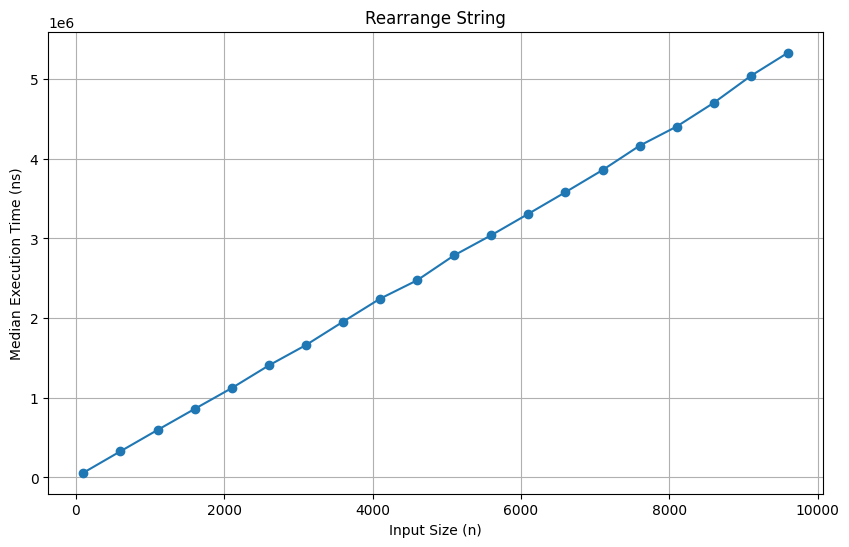

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o')
plt.title("Rearrange String")
plt.xlabel("Input Size (n)")
plt.ylabel("Median Execution Time (ns)")
plt.grid(True)
plt.show()